In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
def remove_unwanted_columns(df):
    """
    Removes specific unwanted columns if they exist in the DataFrame.
    """
    unwanted = [
        'Unnamed: 0', 'Month', 'day_of_week', 
        'Day_of_week', 'pm25_lag1', 'pm25_lag7', 'to_date',
    ]
    
    # Only drop columns that are actually present in the dataframe
    cols_to_drop = [col for col in unwanted if col in df.columns]
    
    return df.drop(columns=cols_to_drop)



def fix_temporal_structure(df, datetime_col='from_date', freq='h'):
    """
    Ensures the dataframe has a continuous datetime index with no gaps.
    """
    df[datetime_col] = pd.to_datetime(df[datetime_col])
    
    # Remove duplicates by taking the mean of entries with the same timestamp
    df = df.groupby(datetime_col).mean(numeric_only=True).reset_index()

    # Set index and fill missing hours
    df = df.set_index(datetime_col)
    df = df.asfreq(freq)
    
    return df



def apply_physical_bounds(df):
    """
    Clips sensor data to realistic physical limits.
    """
    # Pollutants & Wind Speed: Cannot be negative
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].clip(lower=0)
    
    # Humidity: Cannot exceed 100%
    if 'humidity' in df.columns:
        df['humidity'] = df['humidity'].clip(upper=100)
        
    return df



def handle_missing_values(df, max_gap=3):
    """
    Fills gaps using linear interpolation. 
    'max_gap' limits interpolation so we don't 'guess' too much data.
    """
    # Interpolate small gaps linearly
    df = df.interpolate(method='linear', limit=max_gap)
    
    # For larger gaps, use a backfill/forward fill to catch edges
    df = df.ffill().bfill()
    
    return df

In [3]:
def load_and_preprocess_split(train_path, val_path, test_path):
    """
    Loads three CSVs, cleans them using the predefined pipeline, 
    and returns scaled DataFrames + the fitted scaler.
    """
    
    # 1. Load raw data
    datasets = {
        'train': pd.read_csv(train_path),
        'val': pd.read_csv(val_path),
        'test': pd.read_csv(test_path)
    }
    
    processed_dfs = {}
    
    for name, df in datasets.items():
        # Apply the pipeline we built earlier
        # Note: 'city' and 'to_date' are usually dropped for modeling
        df_clean = (df.pipe(remove_unwanted_columns)  # 1. Strip junk first
                      .pipe(fix_temporal_structure)    # 2. Fix time index
                      .pipe(apply_physical_bounds)    # 3. Clip sensor errors
                      .pipe(handle_missing_values))    # 4. Fill NaNs
        
        if 'time_idx' in df_clean.columns:
            df_clean['time_idx'] = df_clean['time_idx'].astype(int)
        processed_dfs[name] = df_clean

    # 2. Feature Scaling (Standardization)
    # We fit ONLY on train to prevent data leakage
        
    return processed_dfs['train'], processed_dfs['val'], processed_dfs['test']

In [4]:
train_file = "/share/ftrscape/lmiddha/hw/data/Train_data.csv"
val_file = "/share/ftrscape/lmiddha/hw/data/Validation_data.csv"
test_file = "/share/ftrscape/lmiddha/hw/data/Test_data.csv"

In [5]:
train_data, val_data, test_data = load_and_preprocess_split(train_file, val_file, test_file)

In [6]:
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2017-01-01 00:00:00,212.535000,326.436250,54.380909,82.325000,51.679091,99.992000,16.894,2.032500,20.7800,791.506,0.565000,12.128,85.467143,0.0,1
2017-01-01 01:00:00,221.626667,349.794286,57.869000,81.743333,50.840000,104.844444,15.530,2.308571,20.2050,791.420,0.595000,11.600,86.110000,0.0,2
2017-01-01 02:00:00,217.650000,336.096250,42.166364,71.381667,43.699091,78.736000,13.922,1.623750,46.0625,791.380,0.498333,11.336,86.748571,0.0,3
2017-01-01 03:00:00,226.055000,307.732500,41.658182,70.268333,38.291818,72.843000,13.780,1.568571,27.9700,791.540,0.531667,10.564,86.732857,0.0,4
2017-01-01 04:00:00,219.325556,277.064286,56.181000,61.455000,34.336000,92.034444,15.322,1.868333,16.5950,791.634,0.386667,9.900,87.377143,0.0,5


In [7]:
train_data.columns

Index(['pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp',
       'wind_speed', 'air_temp', 'humidity', 'rainfall', 'time_idx'],
      dtype='object')

In [8]:
feature_cols=[ 'pm25', 'pm10', 'no', 'nh3', 'no2', 'nox', 'so2', 'co', 'ozone', 'bp',
       'wind_speed', 'air_temp', 'humidity', 'rainfall']
scaler = MinMaxScaler()
scaler.fit(train_data[feature_cols])
train_data[feature_cols] = scaler.transform(train_data[feature_cols])
val_data[feature_cols] = scaler.transform(val_data[feature_cols])
test_data[feature_cols] = scaler.transform(test_data[feature_cols])

In [9]:
train_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2017-01-01 00:00:00,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1
2017-01-01 01:00:00,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2


In [10]:
val_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2023-01-01 00:00:00,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585
2023-01-01 01:00:00,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586


In [11]:
test_data.head(2)

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
from_date,,,,,,,,,,,,,,,
2023-03-01 00:00:00,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.02508,0.347751,0.559211,0.0,54001
2023-03-01 01:00:00,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.02163,0.351402,0.534649,0.0,54002


In [12]:
train_data = train_data.reset_index(drop=True)
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1
1,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2
2,0.254003,0.330607,0.122315,0.267693,0.188049,0.195340,0.169915,0.128538,0.280472,0.207668,0.013831,0.163223,0.887574,0.0,3
3,0.263951,0.302009,0.120730,0.263246,0.157676,0.178996,0.168180,0.124170,0.165346,0.208238,0.015098,0.145396,0.887407,0.0,4
4,0.255986,0.271087,0.166050,0.228039,0.135456,0.232222,0.187014,0.147899,0.092966,0.208573,0.009589,0.130063,0.894238,0.0,5


In [13]:
test_data = test_data.reset_index(drop=True)
test_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.025080,0.347751,0.559211,0.0,54001
1,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.021630,0.351402,0.534649,0.0,54002
2,0.086687,0.222010,0.194948,0.182882,0.160864,0.213559,0.127595,0.103226,0.032776,0.846069,0.021645,0.341923,0.551080,0.0,54003
3,0.081731,0.206593,0.196309,0.171079,0.178890,0.210963,0.109311,0.093880,0.038824,0.845452,0.026326,0.344133,0.552164,0.0,54004
4,0.079842,0.202226,0.181656,0.168230,0.149773,0.211327,0.097874,0.080843,0.042704,0.845457,0.026797,0.342198,0.544343,0.0,54005


In [14]:
val_data = val_data.reset_index(drop=True)
val_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx
0,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585
1,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586
2,0.165000,0.193064,0.110916,0.200291,0.118967,0.129111,0.083353,0.088879,0.031809,0.881702,0.012433,0.167241,0.886555,0.0,52587
3,0.160067,0.185576,0.124561,0.191399,0.115773,0.137774,0.083461,0.089987,0.030547,0.880580,0.011337,0.160481,0.892008,0.0,52588
4,0.149380,0.170272,0.131735,0.187531,0.112380,0.145666,0.068054,0.085447,0.034143,0.880563,0.012740,0.156671,0.895083,0.0,52589


In [15]:
train_data["city"] = "Delhi"
train_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.247949,0.320867,0.160433,0.311409,0.232873,0.254292,0.206213,0.160895,0.119595,0.208117,0.016364,0.181511,0.873987,0.0,1,Delhi
1,0.258709,0.344419,0.171318,0.309085,0.228160,0.267750,0.189554,0.182749,0.115936,0.207811,0.017504,0.169319,0.880803,0.0,2,Delhi
2,0.254003,0.330607,0.122315,0.267693,0.188049,0.195340,0.169915,0.128538,0.280472,0.207668,0.013831,0.163223,0.887574,0.0,3,Delhi
3,0.263951,0.302009,0.120730,0.263246,0.157676,0.178996,0.168180,0.124170,0.165346,0.208238,0.015098,0.145396,0.887407,0.0,4,Delhi
4,0.255986,0.271087,0.166050,0.228039,0.135456,0.232222,0.187014,0.147899,0.092966,0.208573,0.009589,0.130063,0.894238,0.0,5,Delhi


In [16]:
test_data["city"] = "Delhi"
test_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.081741,0.232646,0.266218,0.168774,0.199797,0.292820,0.114118,0.125023,0.031284,0.848249,0.025080,0.347751,0.559211,0.0,54001,Delhi
1,0.090282,0.258060,0.213401,0.183553,0.180402,0.232069,0.108866,0.113532,0.036754,0.846508,0.021630,0.351402,0.534649,0.0,54002,Delhi
2,0.086687,0.222010,0.194948,0.182882,0.160864,0.213559,0.127595,0.103226,0.032776,0.846069,0.021645,0.341923,0.551080,0.0,54003,Delhi
3,0.081731,0.206593,0.196309,0.171079,0.178890,0.210963,0.109311,0.093880,0.038824,0.845452,0.026326,0.344133,0.552164,0.0,54004,Delhi
4,0.079842,0.202226,0.181656,0.168230,0.149773,0.211327,0.097874,0.080843,0.042704,0.845457,0.026797,0.342198,0.544343,0.0,54005,Delhi


In [17]:
val_data["city"] = "Delhi"
val_data.head()

,pm25,pm10,no,nh3,no2,nox,so2,co,ozone,bp,wind_speed,air_temp,humidity,rainfall,time_idx,city
0,0.191747,0.226563,0.148611,0.220066,0.149775,0.161195,0.098529,0.116798,0.032616,0.881160,0.014563,0.175851,0.874877,0.0,52585,Delhi
1,0.185043,0.218535,0.114174,0.218260,0.133553,0.133523,0.091319,0.102693,0.036589,0.880302,0.012512,0.170726,0.878298,0.0,52586,Delhi
2,0.165000,0.193064,0.110916,0.200291,0.118967,0.129111,0.083353,0.088879,0.031809,0.881702,0.012433,0.167241,0.886555,0.0,52587,Delhi
3,0.160067,0.185576,0.124561,0.191399,0.115773,0.137774,0.083461,0.089987,0.030547,0.880580,0.011337,0.160481,0.892008,0.0,52588,Delhi
4,0.149380,0.170272,0.131735,0.187531,0.112380,0.145666,0.068054,0.085447,0.034143,0.880563,0.012740,0.156671,0.895083,0.0,52589,Delhi


### Check if data is correct

In [18]:
import numpy as np

expected = np.arange(train_data["time_idx"].iloc[0], train_data["time_idx"].iloc[0] + len(train_data))
(train_data["time_idx"].values == expected).all()

np.True_

In [19]:
last_train_idx = train_data["time_idx"].iloc[-1]
print("Last train time_idx:", last_train_idx)

Last train time_idx: 52584


In [20]:
expected_start = last_train_idx + 1
expected_end = last_train_idx + len(val_data)
expected = np.arange(expected_start, expected_end + 1)  # inclusive
(val_data["time_idx"].values == expected).all()

np.True_

In [21]:
last_val_idx = val_data["time_idx"].iloc[-1]
print("Last val time_idx:", last_val_idx)

Last val time_idx: 54000


In [22]:
expected_start = last_val_idx + 1
expected_end = last_val_idx + len(test_data)
expected = np.arange(expected_start, expected_end + 1)  # inclusive
(test_data["time_idx"].values == expected).all()

np.True_

In [23]:
import copy
from pathlib import Path
import warnings

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import MultiNormalizer, GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)
from pytorch_forecasting import Baseline
from pytorch_forecasting.metrics import MAE, RMSE
from lightning.pytorch.callbacks import TQDMProgressBar

/usr/local/usrapps/ftrscape/lmiddha/env_ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
from pytorch_forecasting.data.encoders import MultiNormalizer, TorchNormalizer

TARGET_COLS = ["pm25", "no2", "co", "ozone"]

multi_normalizer = MultiNormalizer(
    [TorchNormalizer(method="identity", center=False) for _ in TARGET_COLS]
)

In [26]:
max_prediction_length = 24
max_encoder_length = 360

training = TimeSeriesDataSet(
    train_data,
    time_idx="time_idx",
    target=TARGET_COLS,
    group_ids=["city"],
    min_encoder_length=168,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["city"],
    static_reals=[],
    time_varying_known_categoricals=[],
    variable_groups={},
    time_varying_known_reals=[
        "time_idx", "wind_speed", "air_temp", "humidity", "bp", "rainfall",
    ],
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=[
        "pm10", "pm25", "no", "nh3", "no2", "so2", "co", "ozone", "nox",
    ],
    # identity normalizer because we already scaled with MinMaxScaler
    target_normalizer=multi_normalizer,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

In [27]:
history_for_val = train_data.iloc[-max_encoder_length:]
val_combined = pd.concat([history_for_val, val_data]).reset_index(drop=True)

validation = TimeSeriesDataSet.from_dataset(
    training,
    val_combined,
    predict=False,
    stop_randomization=True
)

In [28]:
train_dataloader = training.to_dataloader(
    train=True, batch_size=128, num_workers=1
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=64, num_workers=1
)

In [29]:
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_forecasting.metrics import MultiLoss, RMSE

In [30]:
TARGET_COLS = ["pm25", "no2", "co", "ozone"]

class LossHistory(pl.Callback):
    def __init__(self, target_cols=None):
        self.train_losses = []
        self.val_losses   = []
        self.target_cols  = target_cols or []

        # per-target val loss storage
        self.val_losses_per_target = {t: [] for t in self.target_cols}

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("train_loss_epoch") or \
               trainer.callback_metrics.get("train_loss")
        if loss is not None:
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        # Overall averaged val loss — same as before
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

        # Per-target val losses — TFT logs these as val_loss_<target>
        for target in self.target_cols:
            key = f"val_loss_{target}"
            t_loss = trainer.callback_metrics.get(key)
            if t_loss is not None:
                self.val_losses_per_target[target].append(t_loss.item())

loss_history = LossHistory(target_cols=TARGET_COLS)

In [32]:
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor() 
tqdm_logger = TQDMProgressBar(refresh_rate =20)
logger = TensorBoardLogger("lightning_logs")
loss_history= LossHistory()


checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints-multi-loss-15days",
    filename="tft-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    save_top_k=3,        
    mode="min",
    save_last=True       
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="gpu",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback, tqdm_logger, checkpoint_callback, loss_history],
    logger=logger,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=128,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=64,
    loss=MultiLoss([RMSE(), RMSE(), RMSE(), RMSE()]),
    output_size=[1, 1, 1, 1],
    log_interval=10, 
    optimizer="adamw",
    reduce_on_plateau_patience=4,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Number of parameters in network: 1672.5k


In [33]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MultiLoss                       │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  3.2 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  238 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  430 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  184 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ ModuleList                      │    516 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.7 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.7 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 643                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 0: 100%|██████████████████████████████████████████████████████████████| 411/411 [07:52<00:00,  0.87it/s, v_num=3, train_loss_step=0.202]
Validation: |                                                                                                           | 0/? [00:00<?, ?it/s]
Validation: |                                                                                                           | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████████████████| 411/411 [07:50<00:00,  0.87it/s, v_num=3, train_loss_step=0.169, val_loss=0.150, train_loss_epoch=0.297]
Validation: |                                                                                                           | 0/? [00:00<?, ?it/s]
Validation: |                                                                                                           | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████████████████| 411/411 [07:51<00:00,  0.87it/s, v_num=3, train_loss_step=0.165, val_loss=0.137, train_loss_epoch=0.187]

In [40]:
history = val_data.iloc[-max_encoder_length:].copy()
step_size = max_prediction_length
total_steps = len(test_data)
targets = ["pm25", "no2", "co", "ozone"]

all_preds   = {t: [] for t in targets}
all_actuals = {t: [] for t in targets}

for start_idx in range(0, total_steps, step_size):
    true_chunk = test_data.iloc[start_idx:start_idx + step_size]
    if len(true_chunk) == 0:
        break

    decoder_df = true_chunk.copy()

    encoder_df = history.iloc[-max_encoder_length:].copy()
    window_df  = pd.concat([encoder_df, decoder_df]).reset_index(drop=True)

    global_time_offset = int(encoder_df["time_idx"].iloc[0])
    window_df["time_idx"] = range(global_time_offset, global_time_offset + len(window_df))
    window_df["time_idx"] = window_df["time_idx"].astype(int)

    window_dataset = TimeSeriesDataSet.from_dataset(
        training,
        window_df,
        predict=True,
        stop_randomization=True
    )
    window_dataloader = window_dataset.to_dataloader(
        train=False, batch_size=64, num_workers=1
    )

    preds = tft.predict(
        window_dataloader,
        mode="prediction",
        trainer_kwargs=dict(accelerator="gpu")
    )

    chunk_len = len(true_chunk)

    pred_chunk = np.stack(
        [preds[i].reshape(-1).cpu().numpy()[:chunk_len] for i in range(len(targets))],
        axis=-1
    ) 
    dummy_pred = np.zeros((pred_chunk.shape[0], len(feature_cols)))
    target_indices = [feature_cols.index(t) for t in targets]
    for i, idx in enumerate(target_indices):
        dummy_pred[:, idx] = pred_chunk[:, i]
    pred_original = scaler.inverse_transform(dummy_pred)[:, target_indices]  


    dummy_act = np.zeros((chunk_len, len(feature_cols)))
    actual_chunk = true_chunk[targets].values       
    for i, idx in enumerate(target_indices):
        dummy_act[:, idx] = actual_chunk[:, i]
    act_original = scaler.inverse_transform(dummy_act)[:, target_indices]    

    for i, t in enumerate(targets):
        all_preds[t].append(pred_original[:, i])
        all_actuals[t].append(act_original[:, i])

    history = pd.concat([history, true_chunk])


all_preds   = {t: np.concatenate(all_preds[t])   for t in targets}
all_actuals = {t: np.concatenate(all_actuals[t]) for t in targets}


for t in targets:
    print(f"{t:8s} | n_points: {len(all_preds[t])} "
          f"| pred range: {all_preds[t].min():.2f} – {all_preds[t].max():.2f} "
          f"| true range: {all_actuals[t].min():.2f} – {all_actuals[t].max():.2f}")


from sklearn.metrics import mean_squared_error, mean_absolute_error

print("\n── Metrics over full 30-day test set (720 points) ──")
results = {}
for t in targets:
    rmse = np.sqrt(mean_squared_error(all_actuals[t], all_preds[t]))
    mae  = mean_absolute_error(all_actuals[t], all_preds[t])
    results[t] = {"RMSE": round(rmse, 4), "MAE": round(mae, 4)}
    print(f"{t:8s}  RMSE: {rmse:.4f}  MAE: {mae:.4f}")

results_df = pd.DataFrame(results).T
print(results_df)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVIC

pm25     | n_points: 744 | pred range: 27.00 – 152.39 | true range: 14.50 – 195.29
no2      | n_points: 744 | pred range: 19.93 – 77.50 | true range: 14.81 – 71.57
co       | n_points: 744 | pred range: 0.64 – 2.08 | true range: 0.54 – 2.61
ozone    | n_points: 744 | pred range: 6.80 – 88.44 | true range: 6.32 – 94.52

── Metrics over full 30-day test set (720 points) ──
pm25      RMSE: 20.6091  MAE: 16.1592
no2       RMSE: 9.9626  MAE: 8.0915
co        RMSE: 0.2695  MAE: 0.1859
ozone     RMSE: 6.6218  MAE: 4.6855
          RMSE      MAE
pm25   20.6091  16.1592
no2     9.9626   8.0915
co      0.2695   0.1859
ozone   6.6218   4.6855


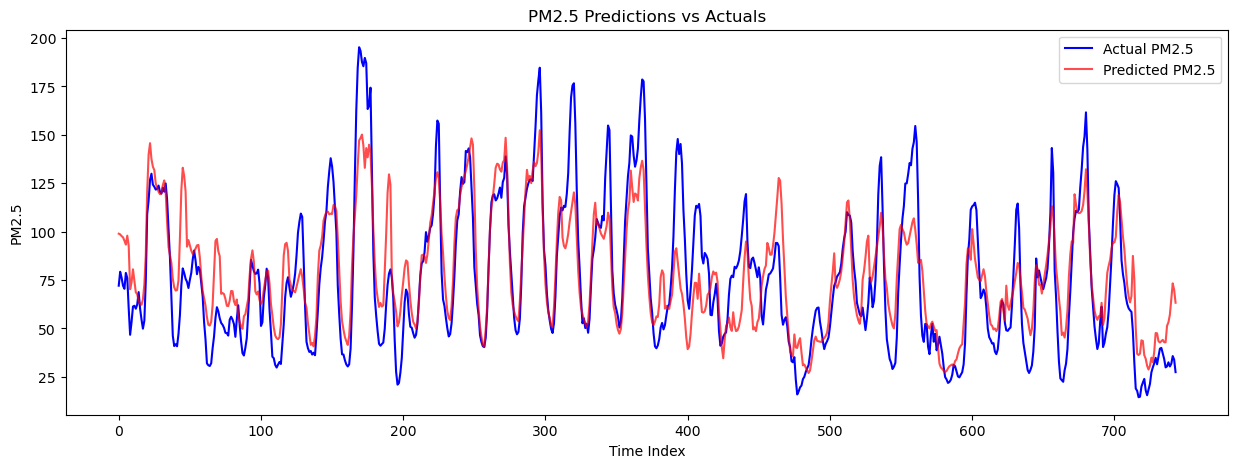

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15,5))
plt.plot(all_actuals['pm25'], label="Actual PM2.5", color="blue")
plt.plot(all_preds['pm25'], label="Predicted PM2.5", color="red", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("PM2.5")
plt.title("PM2.5 Predictions vs Actuals")
plt.legend()
plt.show()

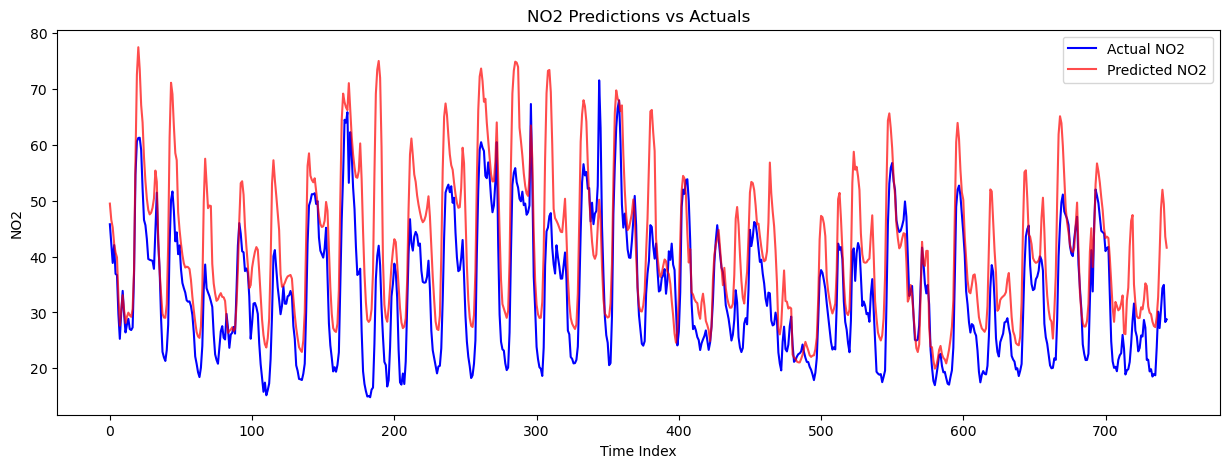

In [36]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15,5))
plt.plot(all_actuals['no2'], label="Actual NO2", color="blue")
plt.plot(all_preds['no2'], label="Predicted NO2", color="red", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("NO2")
plt.title("NO2 Predictions vs Actuals")
plt.legend()
plt.show()

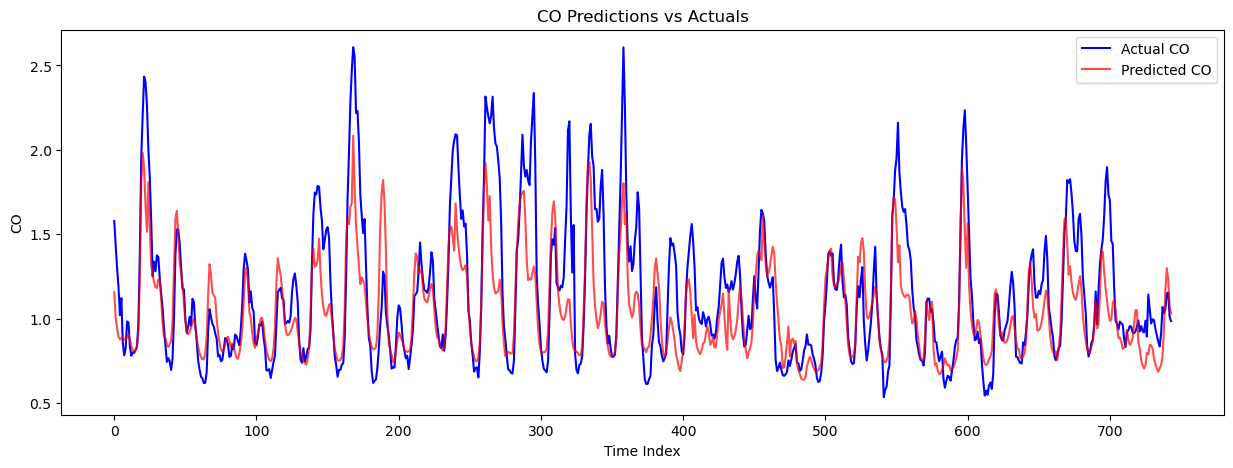

In [37]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15,5))
plt.plot(all_actuals['co'], label="Actual CO", color="blue")
plt.plot(all_preds['co'], label="Predicted CO", color="red", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("CO")
plt.title("CO Predictions vs Actuals")
plt.legend()
plt.show()

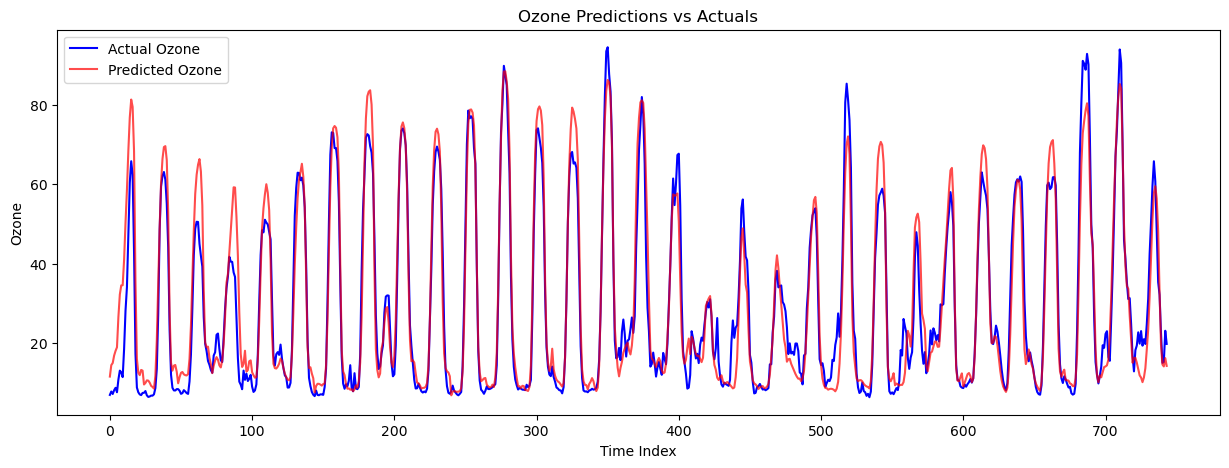

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(all_actuals['ozone'], label="Actual Ozone", color="blue")
plt.plot(all_preds['ozone'], label="Predicted Ozone", color="red", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("Ozone")
plt.title("Ozone Predictions vs Actuals")
plt.legend()
plt.show()

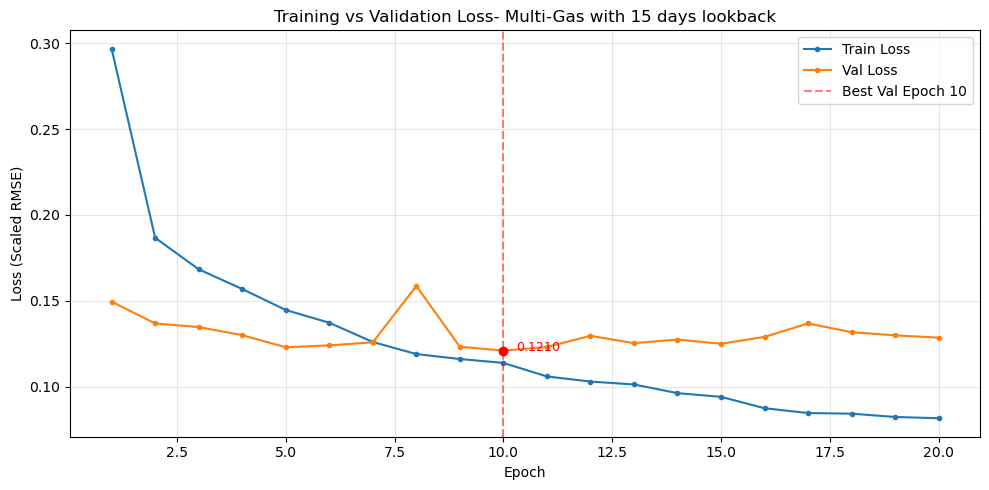

In [39]:
import matplotlib.pyplot as plt

def plot_loss_history(loss_history):
    train_losses = loss_history.train_losses
    val_losses   = loss_history.val_losses

    # Align lengths in case val runs one epoch behind
    min_len = min(len(train_losses), len(val_losses))
    train_losses = train_losses[:min_len]
    val_losses   = val_losses[:min_len]

    epochs = range(1, min_len + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker="o", markersize=3)
    plt.plot(epochs, val_losses,   label="Val Loss",   marker="o", markersize=3)

    # Mark best val loss
    best_epoch = val_losses.index(min(val_losses)) + 1
    best_val   = min(val_losses)
    plt.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best Val Epoch {best_epoch}")
    plt.scatter([best_epoch], [best_val], color="red", zorder=5)
    plt.annotate(f"{best_val:.4f}", xy=(best_epoch, best_val),
                 xytext=(best_epoch + 0.3, best_val), fontsize=9, color="red")

    plt.xlabel("Epoch")
    plt.ylabel("Loss (Scaled RMSE)")
    plt.title("Training vs Validation Loss- Multi-Gas with 15 days lookback")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_curve.png", dpi=150)
    plt.show()

plot_loss_history(loss_history)